In [44]:
! pip install tifffile

In [ ]:
from pathlib import Path
import re

import numpy as np
import matplotlib.pyplot as plt

import tifffile as tf

In [52]:
cache_path = Path('./vessels')
assert cache_path.exists()

regex = r"^svx_(\d+)_(\d+)_(\d+)\.npy$"

svx_coords = []

for f in cache_path.iterdir():
    svx_coord = np.array(re.match(regex, f.name).groups()).astype(int)
    svx_coords.append(svx_coord)

svx_coords = np.array(svx_coords)
dims = np.max(svx_coords, axis=0) - np.min(svx_coords, axis=0)
dims = dims + np.ones_like(dims)

In [53]:
first_file = next(cache_path.iterdir())
first_frag = np.load(first_file)
shape = first_frag.shape
shape

(100, 100, 16)

In [54]:
acc = np.empty(shape * dims, dtype=first_frag.dtype)

for f in cache_path.iterdir():
    svx_coord = np.array(re.match(regex, f.name).groups()).astype(int)
    frag = np.load(f)

    assert frag.shape == shape

    a = svx_coord * shape
    b = a + shape

    x0, y0, z0 = a
    x1, y1, z1 = b

    acc[x0:x1, y0:y1, z0:z1] = frag

In [55]:
print(f'Total Volume: { np.array(acc.shape) * 0.1 } um')
tf.imwrite(cache_path.joinpath('downsampled.tiff'), acc)

Total Volume: [30.  30.  52.8] um


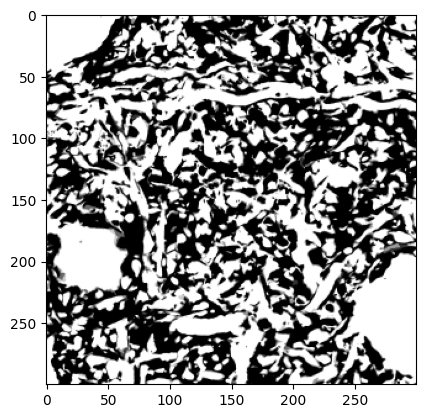

In [43]:
import matplotlib.pyplot as plt

plt.imshow(acc[:,:,0], cmap='gray')